In [2]:
pip install tensorflow

   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 2.9/351.2 MB 21.8 MB/s eta 0:00:16
   ---------------------------------------- 3.7/351.2 MB 10.1 MB/s eta 0:00:35
    --------------------------------------- 5.0/351.2 MB 8.7 MB/s eta 0:00:40
    --------------------------------------- 8.4/351.2 MB 10.6 MB/s eta 0:00:33
   - -------------------------------------- 11.5/351.2 MB 11.5 MB/s eta 0:00:30
   - -------------------------------------- 15.2/351.2 MB 12.7 MB/s eta 0:00:27
   -- ------------------------------------- 17.8/351.2 MB 12.6 MB/s eta 0:00:27
   -- ------------------------------------- 22.3/351.2 MB 13.9 MB/s eta 0:00:24
   --- ------------------------------------ 26.5/351.2 MB 14.6 MB/s eta 0:00:23
   --- ------------------------------------ 30.9/351.2 MB 15.3 MB/s eta 0:00:21
   --- ------------------------------------ 34.6/351.2 MB 15.6 MB/s eta 0:00:21
   ---- ----------------------------------- 38.0/351.2

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires protobuf<7,>=3.20, but you have protobuf 7.35.1 which is incompatible.


First 5 Rows
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0            5.1           3.5            1.4           0.2  Iris-setosa
1            4.9           3.0            1.4           0.2  Iris-setosa
2            4.7           3.2            1.3           0.2  Iris-setosa
3            4.6           3.1            1.5           0.2  Iris-setosa
4            5.0           3.6            1.4           0.2  Iris-setosa

Dataset Shape: (150, 5)
Epoch 1/50


C:\Users\SruthinJayakumaran\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.3542 - loss: 1.2771 - val_accuracy: 0.2500 - val_loss: 1.2787
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3542 - loss: 1.2085 - val_accuracy: 0.2500 - val_loss: 1.2255
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3542 - loss: 1.1482 - val_accuracy: 0.2917 - val_loss: 1.1774
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3542 - loss: 1.0946 - val_accuracy: 0.3333 - val_loss: 1.1319
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.3542 - loss: 1.0436 - val_accuracy: 0.3333 - val_loss: 1.0904
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3646 - loss: 0.9978 - val_accuracy: 0.4167 - val_loss: 1.0524
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3854 - loss: 0.9556 - val_accuracy: 0.4167 - val_loss: 1.0177
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4375 - loss: 0.9168 - val_accuracy: 0.4583 - val_loss: 0.9851
Epoch 9/50


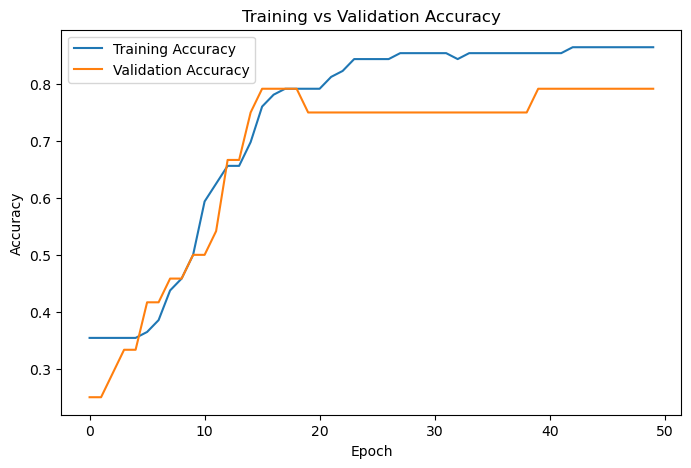

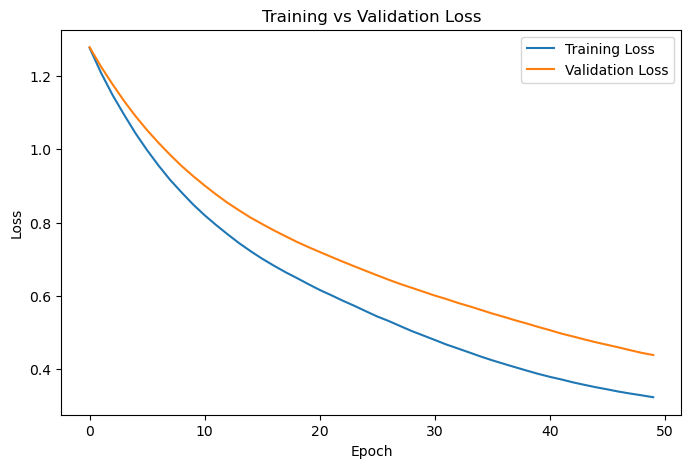

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step



Single Sample Prediction
------------------------
Predicted Species : Iris-virginica
Actual Species    : Iris-virginica

Predictions on Test Set
            Actual        Predicted
0   Iris-virginica   Iris-virginica
1      Iris-setosa      Iris-setosa
2  Iris-versicolor  Iris-versicolor
3  Iris-versicolor  Iris-versicolor
4   Iris-virginica   Iris-virginica
5  Iris-versicolor   Iris-virginica
6   Iris-virginica   Iris-virginica
7   Iris-virginica   Iris-virginica
8      Iris-setosa      Iris-setosa
9  Iris-versicolor  Iris-versicolor

Model saved successfully as iris_ann_model.h5


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

# ==========================================
# Load Dataset
# ==========================================

df = pd.read_csv("Iris.csv")

# Remove Id column if present
if "Id" in df.columns:
    df = df.drop("Id", axis=1)

print("First 5 Rows")
print(df.head())

print("\nDataset Shape:", df.shape)

# ==========================================
# Features and Target
# ==========================================

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# ==========================================
# Encode Target Labels
# ==========================================

encoder = LabelEncoder()
y = encoder.fit_transform(y)

num_classes = len(np.unique(y))

y = to_categorical(y, num_classes)

# ==========================================
# Train-Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ==========================================
# Feature Scaling
# ==========================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==========================================
# Build ANN Model
# ==========================================

model = Sequential()

model.add(Dense(16, activation="relu", input_shape=(X_train.shape[1],)))
model.add(Dense(8, activation="relu"))
model.add(Dense(num_classes, activation="softmax"))

# ==========================================
# Compile Model
# ==========================================

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# ==========================================
# Train Model
# ==========================================

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

# ==========================================
# Evaluate Model
# ==========================================

loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

print("\n==============================")
print("Test Loss :", round(loss, 4))
print("Test Accuracy :", round(accuracy * 100, 2), "%")
print("==============================")

# ==========================================
# Predictions
# ==========================================

y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# ==========================================
# Accuracy
# ==========================================

acc = accuracy_score(y_true, y_pred_classes)

print("\nAccuracy Score")
print(acc)

# ==========================================
# Classification Report
# ==========================================

print("\nClassification Report\n")

print(classification_report(
    y_true,
    y_pred_classes,
    target_names=encoder.classes_
))

# ==========================================
# Confusion Matrix
# ==========================================

cm = confusion_matrix(y_true, y_pred_classes)

print("\nConfusion Matrix\n")
print(cm)

# ==========================================
# Plot Accuracy
# ==========================================

plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

# ==========================================
# Plot Loss
# ==========================================

plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

# ==========================================
# Predict Single Sample
# ==========================================

sample = X_test[0].reshape(1, -1)

prediction = model.predict(sample)

predicted_class = np.argmax(prediction)

print("\nSingle Sample Prediction")
print("------------------------")
print("Predicted Species :", encoder.inverse_transform([predicted_class])[0])
print("Actual Species    :", encoder.inverse_transform([y_true[0]])[0])

# ==========================================
# Predict Entire Dataset (Optional)
# ==========================================

print("\nPredictions on Test Set")

pred_species = encoder.inverse_transform(y_pred_classes)
actual_species = encoder.inverse_transform(y_true)

results = pd.DataFrame({
    "Actual": actual_species,
    "Predicted": pred_species
})

print(results.head(10))

# ==========================================
# Save Model (Optional)
# ==========================================

model.save("iris_ann_model.h5")

print("\nModel saved successfully as iris_ann_model.h5")